# 02 発展課題（自作） 解答 — sRNA サイレンシング最小回路
対象: [`notebooks/02_srna_silencing.ipynb`](../notebooks/02_srna_silencing.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
M, S, P = (Species(x) for x in ['m','s','P'])
A_M, B_M, B_S = 10.0, 1.0, 1.0
def R(a,b,k): return ReactionRule(a,b,k)
def build(a_s, k, translate=False, catalytic=False):
    mdl = NetworkModel()
    for r in [R([],[M],A_M), R([],[S],a_s), R([M],[],B_M), R([S],[],B_S)]:
        mdl.add_reaction_rule(r)
    mdl.add_reaction_rule(R([M,S],[S],k) if catalytic else R([M,S],[],k))
    if translate:
        mdl.add_reaction_rule(R([M],[M,P],5.0)); mdl.add_reaction_rule(R([P],[],0.5))
    return mdl
def steady_m(a_s, k):
    return run_simulation(80.0, y0={}, model=build(a_s,k), solver='ode', ndiv=1, species_list=['m','s']).as_array()[-1][1]

## Q1. ペアリング速度 `k` を下げる（100→5）と閾値の鋭さは?

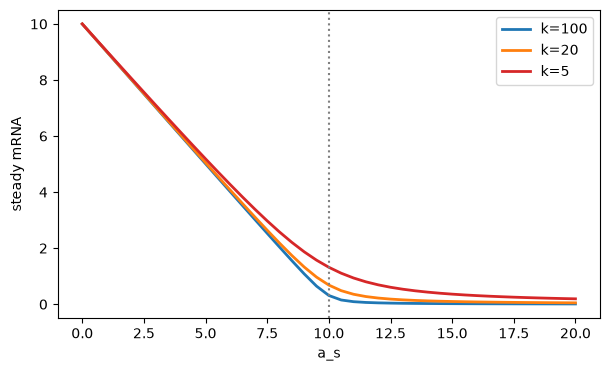

In [2]:
a_grid = np.linspace(0, 20, 41)
fig, ax = plt.subplots(figsize=(7,4))
for k, c in [(100.0,'C0'), (20.0,'C1'), (5.0,'C3')]:
    y = [steady_m(a, k) for a in a_grid]
    ax.plot(a_grid, y, color=c, lw=2, label=f'k={k:.0f}')
ax.axvline(10, ls=':', c='gray'); ax.set_xlabel('a_s'); ax.set_ylabel('steady mRNA'); ax.legend(); plt.show()

**答**: `k` を下げると閾値は**鈍る**（k=100 は a_s=a_m=10 で鋭く折れるが、k=5 ではなだらかで、a_s>10 でも mRNA が残る）。鋭い閾値には強いペアリングが要る。生物学的には、Hfq 結合が弱い/対合が遅いオーソログほど「アナログ寄り」の応答になる、と対応づけられる（→ 05・bio-e）。

## Q2. 翻訳 $m\to m+P$ を足し、P の出力ノイズを見る

In [3]:
def cv_m_P(a_s, k=100.0):
    r = run_simulation(600.0, y0={}, model=build(a_s,k,translate=True), solver='gillespie', ndiv=6000, species_list=['m','s','P'], rndseed=0)
    tail = r.as_array()[1500:]
    cv = lambda x: x.std()/x.mean() if x.mean()>0.3 else np.nan
    return cv(tail[:,1]), cv(tail[:,3])
print(f"{'a_s':>5}{'CV_m':>8}{'CV_P':>8}")
for a in [4, 8, 10]:
    cm, cp = cv_m_P(a); print(f'{a:5d}{cm:8.2f}{cp:8.2f}')

  a_s    CV_m    CV_P
    4    0.51    0.33
    8    1.05    0.61


   10    1.53    0.84


**答**: 全域で $CV_P<CV_m$。長寿命タンパク質（$b_p=0.5<b_m=1$）が mRNA のゆらぎを時間平均で**平滑化**する。ただし閾値へ向かうノイズ増大は P にも伝わる（詳細は 03 で展開）。

## Q3. 触媒的 sRNA（$m+s\to s$）は Michaelis-Menten 的になるか

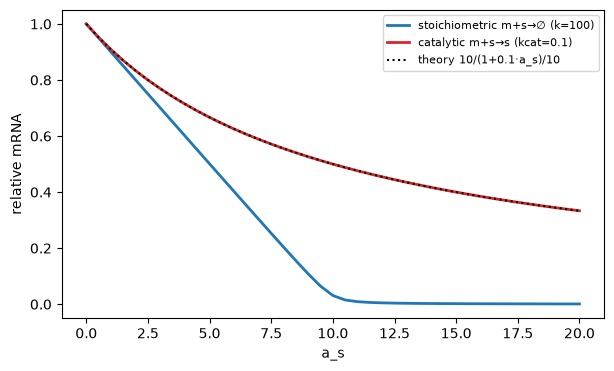

In [4]:
def steady_m_cat(a_s, kcat):
    return run_simulation(120.0, y0={}, model=build(a_s,kcat,catalytic=True), solver='ode', ndiv=1, species_list=['m','s']).as_array()[-1][1]
a_grid = np.linspace(0, 20, 41)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(a_grid, [steady_m(a,100.0)/A_M for a in a_grid], 'C0', lw=2, label='stoichiometric m+s→∅ (k=100)')
ax.plot(a_grid, [steady_m_cat(a,0.1)/A_M for a in a_grid], 'C3', lw=2, label='catalytic m+s→s (kcat=0.1)')
ax.plot(a_grid, 10/(1+0.1*a_grid)/A_M, 'k:', label='theory 10/(1+0.1·a_s)/10')
ax.set_xlabel('a_s'); ax.set_ylabel('relative mRNA'); ax.legend(fontsize=8); plt.show()

**答**: 触媒的（sRNA 再利用）だと閾値が消え、$\langle m\rangle=a_m/(b_m+k_{cat}a_s/b_s)$ の**双曲線（MM 的）**になり理論式と一致。ゼロには漸近するだけで到達しない。ただし 05 で見たとおり、この「graded」は触媒に弱い速度を与えた結果であって、速度を揃えると崩れる点に注意。

## Q4.（考察）bio-a: オーソログ間の結合様式の差を $k$・$b_s$ の差として

**答（考察）**: このモデルの閾値の鋭さは主に $k$（ペアリング/共分解の速さ）で決まり、閾値の位置は転写バランス $a_s$ vs $a_m$、応答の残り方は $b_s$（sRNA 寿命）で調整される。
Hfq のオーソログ間で **proximal 面（sRNA 結合）や rim の保存度**が違えば有効 $k$ が変わり、Firmicutes のようにテール/rim が弱い系統は $k$ が小さい＝**アナログ寄り**、γ-proteobacteria のように rim が強い系統は $k$ 大＝**デジタル（閾値）寄り**、と予測できる。この定量化は新プロジェクト **bio-e** で代表オーソログを使って実施する（本notebookは概念の確認まで）。